In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import string
from matplotlib.cm import coolwarm
from matplotlib import cm
from typing import NamedTuple


In [18]:
class Results(NamedTuple):
    name: str
    avg_sts: float
    alignment: float
    uniformity: float

    @property
    def full_name(self):
        return f"{self.name} ({self.avg_sts})"


results = [
    Results("Sup. SimCSE$^+$", 81.6, 0.24, -3.65),
    Results("Unsup. SimCSE", 76.25, 0.24, -2.6),
    Results("Avg. BERT", 56.7, 0.19, -1.4),
    Results("SBERT$^+$", 74.9, 0.19, -3.0),
    Results("SBERT-flow$^+$", 76.6, 0.44, -3.6),
    Results("SBERT-whitening$^+$", 77.0, 0.5, -3.8),
    Results("BERT-flow", 66.6, 0.55, -3.7),
    Results("BERT-whitening", 66.3, 0.64, -3.8),
    Results("$\mathbf{ADO}$", 76.72, 0.1790, -2.3710),
]

c = [r.avg_sts for r in results]
s = [150] * len(results)

df = pd.DataFrame(
    {
        "x": np.asarray([r.uniformity for r in results]),
        "y": np.asarray([r.alignment for r in results]),
    },
    index=[r.full_name for r in results],
)

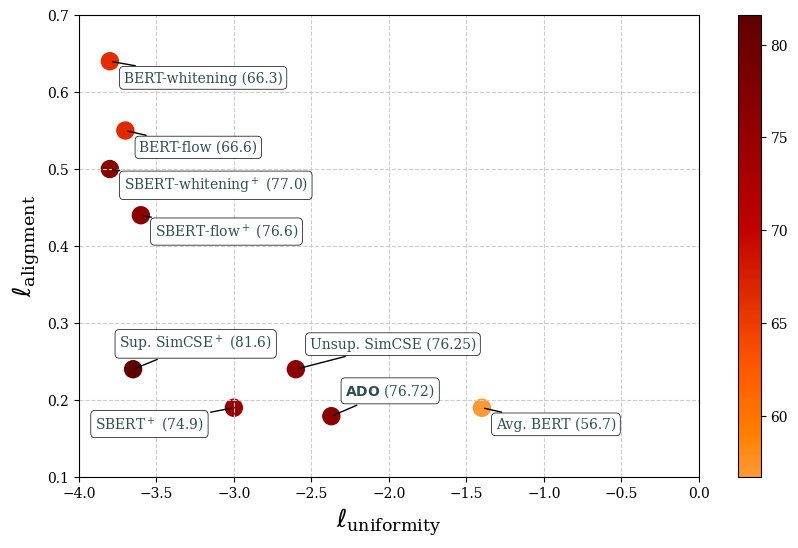

In [67]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np


def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        "trunc({n},{a:.2f},{b:.2f})".format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)),
    )
    return new_cmap


plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams["font.cursive"] = ["Times New Roman"] + plt.rcParams["font.cursive"]

fig, ax = plt.subplots()
fig.set_figheight(6)
fig.set_figwidth(10)
df.plot("x", "y", kind="scatter", ax=ax)
cmap = cm.get_cmap("gist_heat_r")
cmap = truncate_colormap(cmap, 0.2, 0.75)

plt.grid()
ax.grid(which="major", color="#CCCCCC", linestyle="--")
ax.grid(which="minor", color="#CCCCCC", linestyle=":")
sct = ax.scatter(df["x"], df["y"], c=c, cmap=cmap, s=s)


font = dict(fontname="Times New Roman", color="darkslategrey")

plt.xlim([-4, 0])
plt.ylim([0.1, 0.7])


cb = plt.colorbar(sct)


i_y = 1
i_x = 1
for k, v in df.iterrows():
    i_y = -1 if "BERT" in k else 1
    i_x = -10 if "SBERT$^+$" in k else 1
    i_x = -1 if "Sup" in k else i_x
    ax.annotate(
        k,
        v,
        xytext=(10 * i_x, 15 * i_y),
        textcoords="offset points",
        fontsize=10,
        color="darkslategrey",
        bbox=dict(boxstyle="round", fc="white", ec="black", lw=0.5),
        arrowprops=dict(arrowstyle="-"),
    )
plt.ylabel(r"$\ell_{\mathdefault{alignment}}$", fontsize=18)
plt.xlabel(r"$\ell_{\mathdefault{uniformity}}$", fontsize=18)
plt.savefig("alignment_vs_uniformity.pdf", dpi=300, bbox_inches="tight")
